# IPL Performance Analytics Dashboard — Exploratory Data Analysis

## 1. Project / EDA objective

This notebook investigates the structure, completeness, relationships, and analytical content of the raw IPL match-level and ball-by-ball datasets. It asks focused questions about seasons, teams, tosses, batting, bowling, players, venues, and outcomes.

**Scope boundary:** the CSV files are loaded read-only and explored exactly as supplied. Historical team names, venues, cities, and season labels are not normalized. No cleaned data, feature tables, Tableau extracts, or databases are created.

## 2. Imports and configuration

Only Phase 2 dependencies are used. Path resolution supports execution from the repository root or the `notebooks` directory without a machine-specific path.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
%matplotlib inline

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")
CHART_COLOR, ACCENT_COLOR = "#2F6B8A", "#E07A5F"

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
MATCHES_PATH = RAW_DATA_DIR / "matches.csv"
DELIVERIES_PATH = RAW_DATA_DIR / "deliveries.csv"
assert MATCHES_PATH.exists() and DELIVERIES_PATH.exists(), "Expected raw CSV files were not found."
print("Data sources: data/raw/matches.csv and data/raw/deliveries.csv")

Data sources: data/raw/matches.csv and data/raw/deliveries.csv


## 3. Load raw datasets

`matches.csv` has one row per match; `deliveries.csv` has one row per recorded delivery. Loading is separate from cleaning.

In [2]:
matches = pd.read_csv(MATCHES_PATH, low_memory=False)
deliveries = pd.read_csv(DELIVERIES_PATH, low_memory=False)
display(pd.DataFrame({"rows": [len(matches), len(deliveries)], "columns": [matches.shape[1], deliveries.shape[1]]}, index=["matches", "deliveries"]))
display(matches.head(3))
display(deliveries.head(3))
print("Match columns:", matches.columns.tolist())
print("Delivery columns:", deliveries.columns.tolist())

,rows,columns
matches,1095,20
deliveries,260920,17


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.00,223.00,20.00,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.00,241.00,20.00,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.00,130.00,20.00,N,NaN,Aleem Dar,GA Pratapkumar


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN


Match columns: ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']
Delivery columns: ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


## 4. Dataset structure

The schema profile shows types, populated rows, and cardinality. Numeric summaries exclude identifiers because IDs are labels rather than continuous measures.

In [3]:
def schema_summary(frame):
    return pd.DataFrame({"dtype": frame.dtypes.astype(str), "non_null_rows": frame.notna().sum(), "unique_non_null": frame.nunique(dropna=True)})

display(schema_summary(matches))
display(schema_summary(deliveries))
display(matches[["result_margin", "target_runs", "target_overs"]].describe().T)
display(deliveries[["inning", "over", "ball", "batsman_runs", "extra_runs", "total_runs", "is_wicket"]].describe().T)

,dtype,non_null_rows,unique_non_null
id,int64,1095,1095
season,str,1095,17
city,str,1044,36
date,str,1095,823
match_type,str,1095,8
player_of_match,str,1090,291
venue,str,1095,58
team1,str,1095,19
team2,str,1095,19
toss_winner,str,1095,19


,dtype,non_null_rows,unique_non_null
match_id,int64,260920,1095
inning,int64,260920,6
batting_team,str,260920,19
bowling_team,str,260920,19
over,int64,260920,20
ball,int64,260920,11
batter,str,260920,673
bowler,str,260920,530
non_striker,str,260920,663
batsman_runs,int64,260920,7


,count,mean,std,min,25%,50%,75%,max
result_margin,"1,076.00",17.26,21.79,1.00,6.00,8.00,20.00,146.00
target_runs,"1,092.00",165.68,33.43,43.00,146.00,166.00,187.00,288.00
target_overs,"1,092.00",19.76,1.58,5.00,20.00,20.00,20.00,20.00


,count,mean,std,min,25%,50%,75%,max
inning,"260,920.00",1.48,0.50,1.00,1.00,1.00,2.00,6.00
over,"260,920.00",9.20,5.68,0.00,4.00,9.00,14.00,19.00
ball,"260,920.00",3.62,1.81,1.00,2.00,4.00,5.00,11.00
batsman_runs,"260,920.00",1.27,1.64,0.00,0.00,1.00,1.00,6.00
extra_runs,"260,920.00",0.07,0.34,0.00,0.00,0.00,0.00,7.00
total_runs,"260,920.00",1.33,1.63,0.00,0.00,1.00,1.00,7.00
is_wicket,"260,920.00",0.05,0.22,0.00,0.00,0.00,0.00,1.00


## 5. Missing-value analysis

A null is not automatically a defect. Dismissal fields should be null when no wicket occurred, and `method` should be blank when D/L was not used. Counts and percentages are quantified before interpretation.

,missing_count,missing_percent
method,1074,98.08
city,51,4.66
result_margin,19,1.74
winner,5,0.46
player_of_match,5,0.46
target_runs,3,0.27
target_overs,3,0.27


,missing_count,missing_percent
fielder,251566,96.41
player_dismissed,247970,95.04
dismissal_kind,247970,95.04
extras_type,246795,94.59


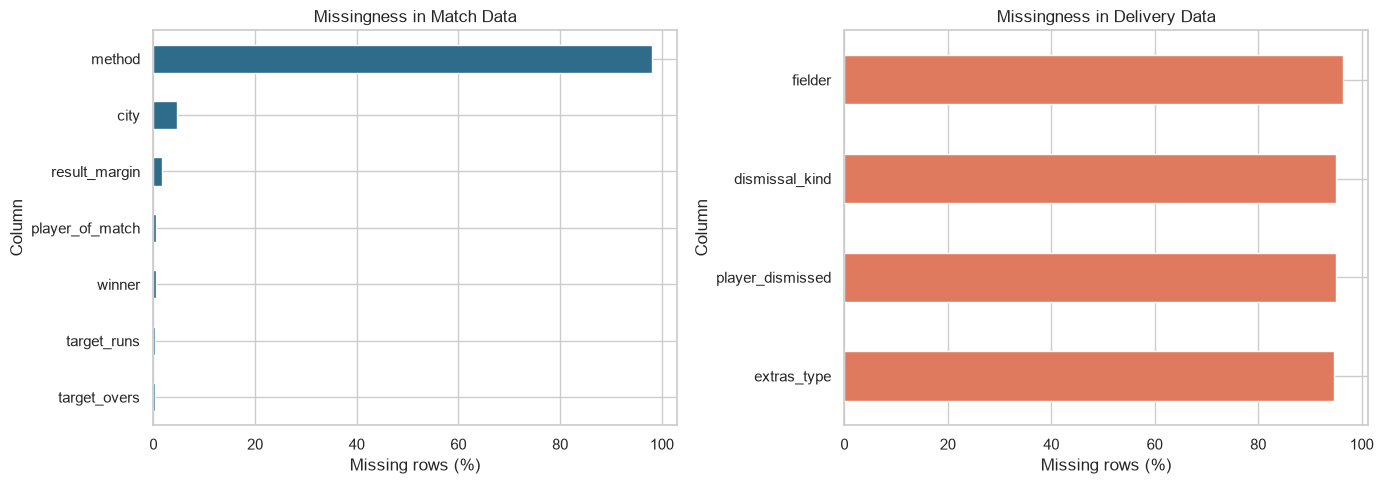

In [4]:
def missing_summary(frame):
    counts = frame.isna().sum()
    result = pd.DataFrame({"missing_count": counts, "missing_percent": counts.div(len(frame)).mul(100)})
    return result.loc[result["missing_count"].gt(0)].sort_values("missing_percent", ascending=False)

matches_missing = missing_summary(matches)
deliveries_missing = missing_summary(deliveries)
display(matches_missing)
display(deliveries_missing)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
matches_missing.sort_values("missing_percent")["missing_percent"].plot.barh(ax=axes[0], color=CHART_COLOR)
deliveries_missing.sort_values("missing_percent")["missing_percent"].plot.barh(ax=axes[1], color=ACCENT_COLOR)
axes[0].set(title="Missingness in Match Data", xlabel="Missing rows (%)", ylabel="Column")
axes[1].set(title="Missingness in Delivery Data", xlabel="Missing rows (%)", ylabel="Column")
plt.tight_layout(); plt.show()

In [5]:
conditional_null_checks = pd.Series({
    "No-result matches missing winner": matches.loc[matches["result"].eq("no result"), "winner"].isna().sum(),
    "Tie/no-result matches missing margin": matches.loc[matches["result"].isin(["tie", "no result"]), "result_margin"].isna().sum(),
    "Non-wicket rows missing dismissed player": deliveries.loc[deliveries["is_wicket"].eq(0), "player_dismissed"].isna().sum(),
    "Wicket rows missing dismissed player": deliveries.loc[deliveries["is_wicket"].eq(1), "player_dismissed"].isna().sum(),
    "Positive-extra rows missing extras type": deliveries.loc[deliveries["extra_runs"].gt(0), "extras_type"].isna().sum(),
}, name="row_count")
display(conditional_null_checks.to_frame())
print("Missing city values by venue:")
display(matches.loc[matches["city"].isna(), "venue"].value_counts().to_frame("missing_city_rows"))

,row_count
No-result matches missing winner,5
Tie/no-result matches missing margin,19
Non-wicket rows missing dismissed player,247970
Wicket rows missing dismissed player,0
Positive-extra rows missing extras type,0


Missing city values by venue:


,missing_city_rows
venue,
Dubai International Cricket Stadium,33
Sharjah Cricket Stadium,18


## 6. Duplicate and key analysis

The match key is `id`; the delivery key is `match_id + inning + over + ball`. Both directions of the one-to-many relationship are checked.

In [6]:
delivery_key = ["match_id", "inning", "over", "ball"]
match_ids, delivery_match_ids = set(matches["id"]), set(deliveries["match_id"])
checks = [
    ("No exact duplicate matches", matches.duplicated().sum()),
    ("No exact duplicate deliveries", deliveries.duplicated().sum()),
    ("Unique matches.id", matches["id"].duplicated().sum()),
    ("Unique delivery composite key", deliveries.duplicated(delivery_key).sum()),
    ("No null matches.id", matches["id"].isna().sum()),
    ("No null deliveries.match_id", deliveries["match_id"].isna().sum()),
    ("No delivery IDs absent from matches", len(delivery_match_ids - match_ids)),
    ("No matches without deliveries", len(match_ids - delivery_match_ids)),
]
key_check_summary = pd.DataFrame(checks, columns=["check", "issue_count"])
key_check_summary["status"] = np.where(key_check_summary["issue_count"].eq(0), "PASS", "FAIL")
display(key_check_summary[["check", "status", "issue_count"]])
print(f"Relationship: matches.id (1) -> deliveries.match_id (many), covering {len(match_ids):,} matches.")

,check,status,issue_count
0,No exact duplicate matches,PASS,0
1,No exact duplicate deliveries,PASS,0
2,Unique matches.id,PASS,0
3,Unique delivery composite key,PASS,0
4,No null matches.id,PASS,0
5,No null deliveries.match_id,PASS,0
6,No delivery IDs absent from matches,PASS,0
7,No matches without deliveries,PASS,0


Relationship: matches.id (1) -> deliveries.match_id (many), covering 1,095 matches.


## 7. IPL overview

This establishes dataset coverage before performance comparisons. Season values remain in original source order and form.

,value
Matches,1095
Season labels,17
Raw team-name values,19
Players across available fields,741
Ties,14
No results,5
Super-over matches,14
D/L matches,21


,matches
match_type,
League,1029
Final,17
Qualifier 1,14
Qualifier 2,14
Eliminator,11
Semi Final,6
Elimination Final,3
3rd Place Play-Off,1


,matches
result,
wickets,578
runs,498
tie,14
no result,5


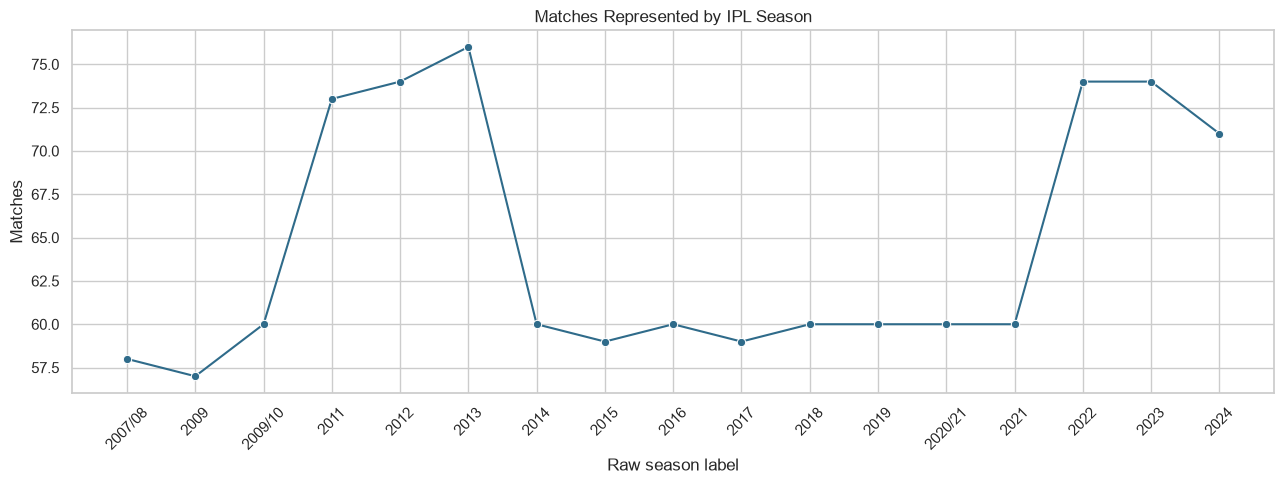

In [7]:
all_teams = set(matches["team1"]) | set(matches["team2"])
all_players = set(matches["player_of_match"].dropna().astype(str))
for column in ["batter", "bowler", "non_striker", "player_dismissed", "fielder"]:
    all_players.update(deliveries[column].dropna().astype(str))
overview = pd.Series({
    "Matches": matches["id"].nunique(), "Season labels": matches["season"].nunique(),
    "Raw team-name values": len(all_teams), "Players across available fields": len(all_players),
    "Ties": matches["result"].eq("tie").sum(), "No results": matches["result"].eq("no result").sum(),
    "Super-over matches": matches["super_over"].eq("Y").sum(), "D/L matches": matches["method"].eq("D/L").sum(),
}, name="value")
display(overview.to_frame())
season_order = matches["season"].drop_duplicates().tolist()
matches_by_season = matches["season"].value_counts().reindex(season_order)
display(matches["match_type"].value_counts().to_frame("matches"))
display(matches["result"].value_counts().to_frame("matches"))
fig, ax = plt.subplots(figsize=(13, 5))
sns.lineplot(x=matches_by_season.index, y=matches_by_season.values, marker="o", color=CHART_COLOR, ax=ax)
ax.set(title="Matches Represented by IPL Season", xlabel="Raw season label", ylabel="Matches")
ax.tick_params(axis="x", rotation=45); plt.tight_layout(); plt.show()

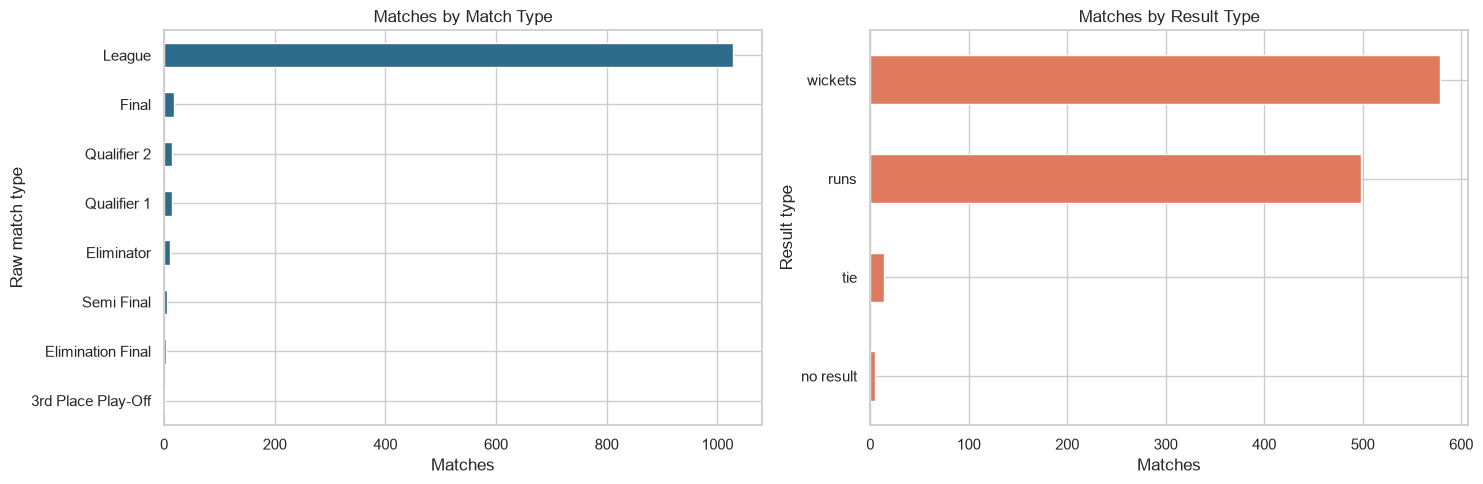

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
matches["match_type"].value_counts().sort_values().plot.barh(ax=axes[0], color=CHART_COLOR)
matches["result"].value_counts().sort_values().plot.barh(ax=axes[1], color=ACCENT_COLOR)
axes[0].set(title="Matches by Match Type", xlabel="Matches", ylabel="Raw match type")
axes[1].set(title="Matches by Result Type", xlabel="Matches", ylabel="Result type")
plt.tight_layout(); plt.show()

## 8. Team analysis

Raw team strings remain distinct. Win percentage is wins divided by all appearances, meaning no-results remain in the denominator. `losses_or_no_result` is intentionally labeled because a missing winner is not necessarily a loss.

,matches_played,wins,toss_wins,losses_or_no_result,win_percentage
Mumbai Indians,261,144,143,117,55.17
Chennai Super Kings,238,138,122,100,57.98
Kolkata Knight Riders,251,131,122,120,52.19
Royal Challengers Bangalore,240,116,113,124,48.33
Rajasthan Royals,221,112,120,109,50.68
Sunrisers Hyderabad,182,88,88,94,48.35
Kings XI Punjab,190,88,85,102,46.32
Delhi Daredevils,161,67,80,94,41.61
Delhi Capitals,91,48,50,43,52.75
Deccan Chargers,75,29,43,46,38.67


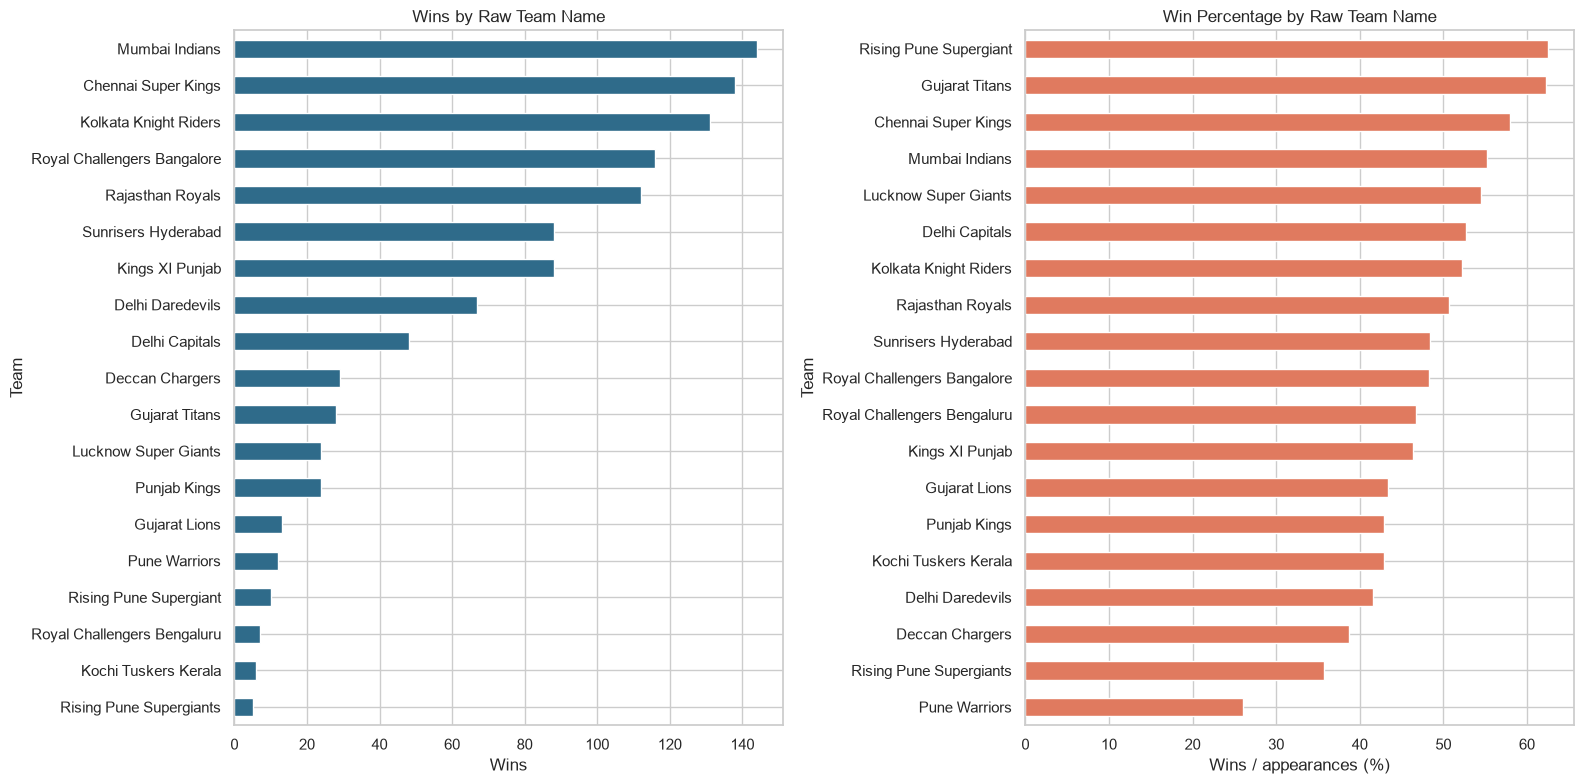

In [9]:
team_appearances = pd.concat([matches["team1"], matches["team2"]]).value_counts()
team_summary = pd.DataFrame({"matches_played": team_appearances, "wins": matches["winner"].value_counts(), "toss_wins": matches["toss_winner"].value_counts()}).fillna(0)
team_summary[["matches_played", "wins", "toss_wins"]] = team_summary[["matches_played", "wins", "toss_wins"]].astype(int)
team_summary["losses_or_no_result"] = team_summary["matches_played"] - team_summary["wins"]
team_summary["win_percentage"] = team_summary["wins"].div(team_summary["matches_played"]).mul(100)
team_summary = team_summary.sort_values(["wins", "win_percentage"], ascending=False)
display(team_summary)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
team_summary.sort_values("wins")["wins"].plot.barh(ax=axes[0], color=CHART_COLOR)
team_summary.sort_values("win_percentage")["win_percentage"].plot.barh(ax=axes[1], color=ACCENT_COLOR)
axes[0].set(title="Wins by Raw Team Name", xlabel="Wins", ylabel="Team")
axes[1].set(title="Win Percentage by Raw Team Name", xlabel="Wins / appearances (%)", ylabel="Team")
plt.tight_layout(); plt.show()

In [10]:
name_groups = {
    "Delhi": ["Delhi Daredevils", "Delhi Capitals"],
    "Punjab": ["Kings XI Punjab", "Punjab Kings"],
    "Bangalore/Bengaluru": ["Royal Challengers Bangalore", "Royal Challengers Bengaluru"],
    "Rising Pune": ["Rising Pune Supergiants", "Rising Pune Supergiant"],
}
variation_rows = [{"candidate_group": group, "raw_team_name": name, "observed": name in all_teams} for group, names in name_groups.items() for name in names]
display(pd.DataFrame(variation_rows))
print("Review candidates only: no team names have been merged.")

,candidate_group,raw_team_name,observed
0,Delhi,Delhi Daredevils,True
1,Delhi,Delhi Capitals,True
2,Punjab,Kings XI Punjab,True
3,Punjab,Punjab Kings,True
4,Bangalore/Bengaluru,Royal Challengers Bangalore,True
5,Bangalore/Bengaluru,Royal Challengers Bengaluru,True
6,Rising Pune,Rising Pune Supergiants,True
7,Rising Pune,Rising Pune Supergiant,True


Review candidates only: no team names have been merged.


## 9. Toss analysis

The toss-to-match relationship excludes no-results because they have no winner. It describes association, not causation.

,matches
toss_decision,
field,704
bat,391


,value
Decided matches,"1,090.00"
Toss winner also won,554.00
Rate (%),50.83


,decided_matches,toss_winner_wins,toss_winner_win_rate_pct
season,,,
2007/08,58,28,48.28
2009,57,33,57.89
2009/10,60,31,51.67
2011,72,38,52.78
2012,74,33,44.59
2013,76,36,47.37
2014,60,30,50.00
2015,57,28,49.12
2016,60,34,56.67


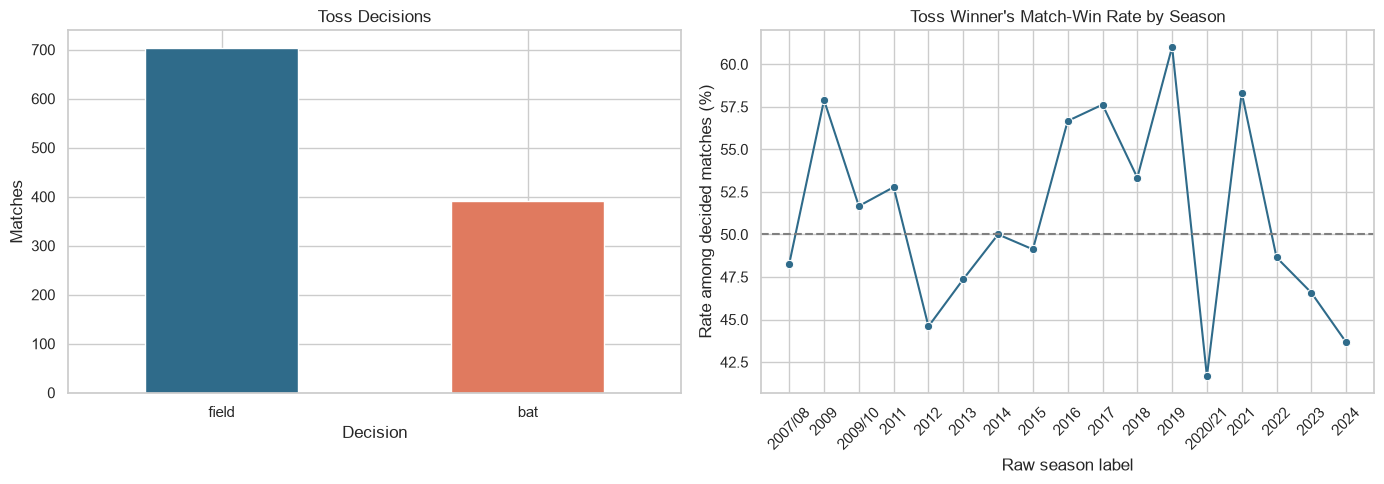

In [11]:
toss_decisions = matches["toss_decision"].value_counts()
decided_matches = matches.loc[matches["winner"].notna()]
toss_winner_won = decided_matches["toss_winner"].eq(decided_matches["winner"])
display(toss_decisions.to_frame("matches"))
display(pd.Series({"Decided matches": len(decided_matches), "Toss winner also won": toss_winner_won.sum(), "Rate (%)": toss_winner_won.mean() * 100}, name="value").to_frame())
season_toss = decided_matches.assign(toss_winner_won=toss_winner_won).groupby("season", sort=False)["toss_winner_won"].agg(["count", "sum", "mean"])
season_toss["mean"] *= 100
display(season_toss.rename(columns={"count": "decided_matches", "sum": "toss_winner_wins", "mean": "toss_winner_win_rate_pct"}))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
toss_decisions.plot.bar(ax=axes[0], color=[CHART_COLOR, ACCENT_COLOR], rot=0)
sns.lineplot(x=season_toss.index, y=season_toss["mean"], marker="o", color=CHART_COLOR, ax=axes[1])
axes[0].set(title="Toss Decisions", xlabel="Decision", ylabel="Matches")
axes[1].axhline(50, color="gray", linestyle="--"); axes[1].set(title="Toss Winner's Match-Win Rate by Season", xlabel="Raw season label", ylabel="Rate among decided matches (%)")
axes[1].tick_params(axis="x", rotation=45); plt.tight_layout(); plt.show()

## 10. Batting analysis

The delivery data supports aggregate batter runs, extras, boundaries, team scoring, and season scoring. These are in-memory EDA summaries, not persisted feature tables.

,value
Total runs,347756
Batter runs,330064
Extras,17692
Fours,29850
Sixes,13051


,total_runs_including_extras
batting_team,
Mumbai Indians,42176
Kolkata Knight Riders,39331
Chennai Super Kings,38629
Royal Challengers Bangalore,37692
Rajasthan Royals,34747
Kings XI Punjab,30064
Sunrisers Hyderabad,29071
Delhi Daredevils,24296
Delhi Capitals,14900


,batter_runs,fours,sixes
batter,,,
V Kohli,"8,014.00",708,273
S Dhawan,"6,769.00",768,153
RG Sharma,"6,630.00",599,281
DA Warner,"6,567.00",663,236
SK Raina,"5,536.00",506,204
MS Dhoni,"5,243.00",363,252
AB de Villiers,"5,181.00",414,253
CH Gayle,"4,997.00",408,359
RV Uthappa,"4,954.00",481,182


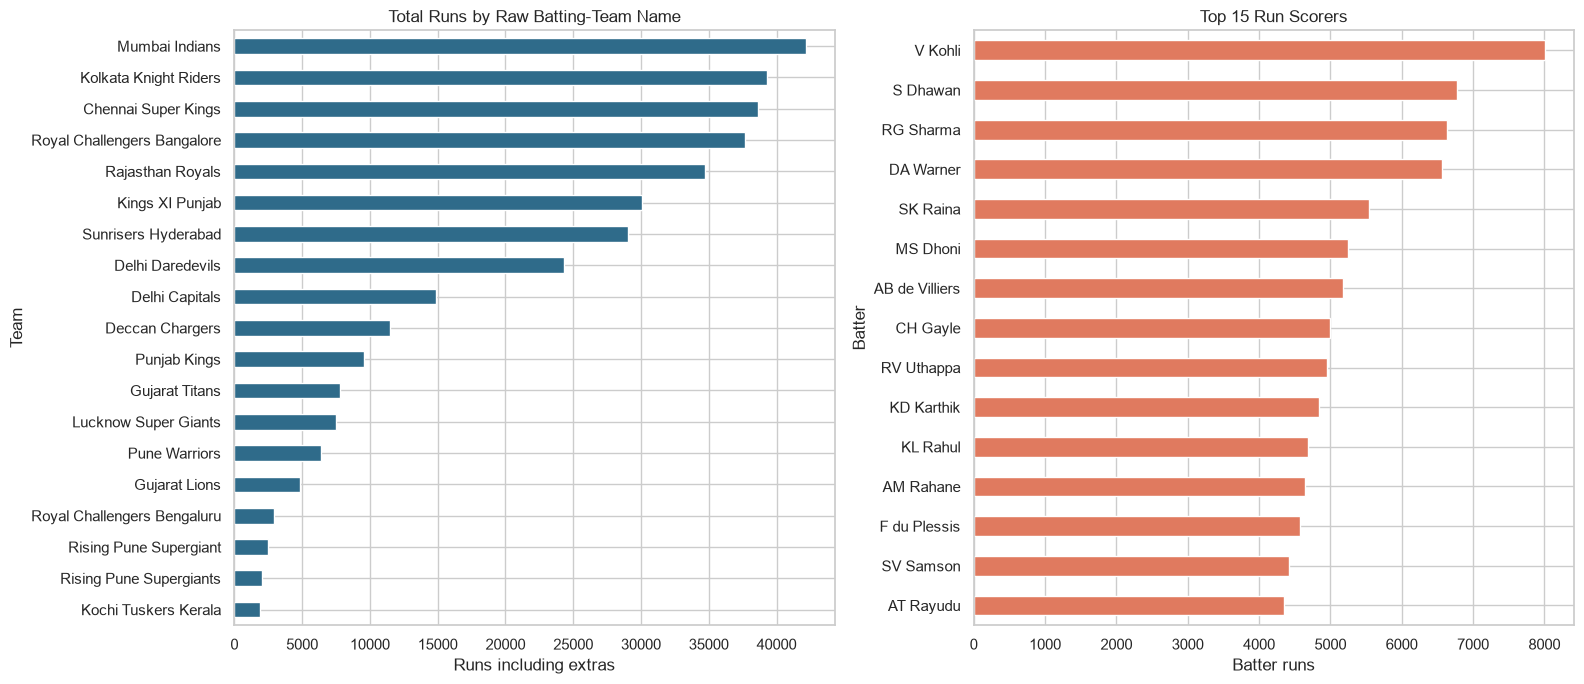

In [12]:
batting_totals = pd.Series({"Total runs": deliveries["total_runs"].sum(), "Batter runs": deliveries["batsman_runs"].sum(), "Extras": deliveries["extra_runs"].sum(), "Fours": deliveries["batsman_runs"].eq(4).sum(), "Sixes": deliveries["batsman_runs"].eq(6).sum()}, name="value")
team_runs = deliveries.groupby("batting_team")["total_runs"].sum().sort_values(ascending=False)
top_batters = deliveries.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False).head(15)
batter_boundaries = deliveries.assign(fours=deliveries["batsman_runs"].eq(4).astype(int), sixes=deliveries["batsman_runs"].eq(6).astype(int)).groupby("batter")[["fours", "sixes"]].sum()
display(batting_totals.to_frame())
display(team_runs.to_frame("total_runs_including_extras"))
display(pd.concat([top_batters.rename("batter_runs"), batter_boundaries], axis=1).loc[top_batters.index])
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
team_runs.sort_values().plot.barh(ax=axes[0], color=CHART_COLOR)
top_batters.sort_values().plot.barh(ax=axes[1], color=ACCENT_COLOR)
axes[0].set(title="Total Runs by Raw Batting-Team Name", xlabel="Runs including extras", ylabel="Team")
axes[1].set(title="Top 15 Run Scorers", xlabel="Batter runs", ylabel="Batter")
plt.tight_layout(); plt.show()

,total_runs,batter_runs,extras
season,,,
2007/08,17937,16809,1128
2009,16353,15376,977
2009/10,18883,17754,1129
2011,21154,19928,1226
2012,22453,21323,1130
2013,22602,21487,1115
2014,18931,17943,988
2015,18353,17427,926
2016,18862,17962,900


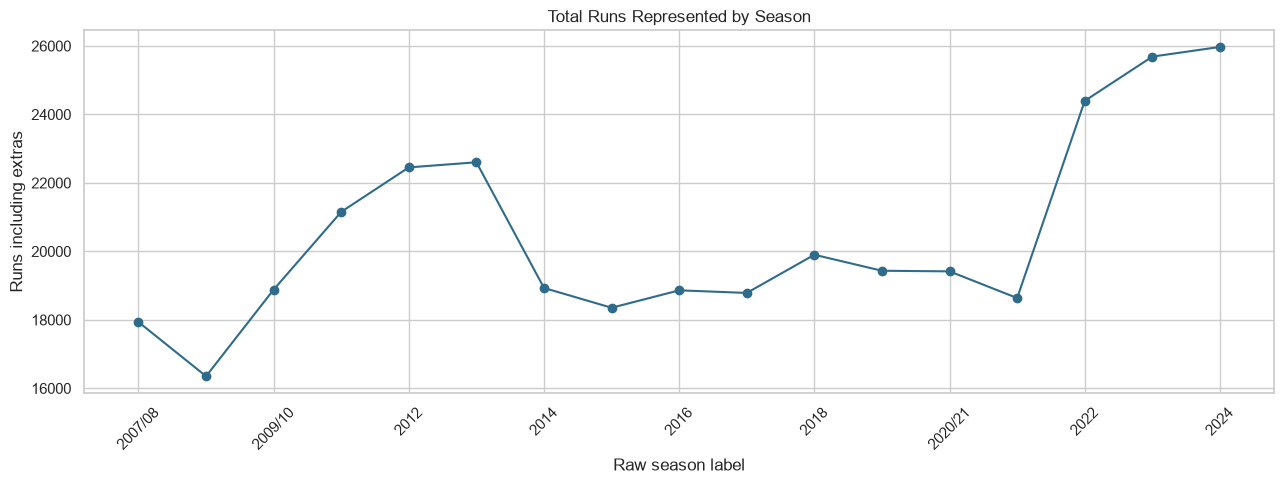

In [13]:
deliveries_with_season = deliveries.merge(matches[["id", "season"]], left_on="match_id", right_on="id", how="left", validate="many_to_one")
season_scoring = deliveries_with_season.groupby("season", sort=False).agg(total_runs=("total_runs", "sum"), batter_runs=("batsman_runs", "sum"), extras=("extra_runs", "sum"))
display(season_scoring)
ax = season_scoring["total_runs"].plot(figsize=(13, 5), marker="o", color=CHART_COLOR, title="Total Runs Represented by Season")
ax.set(xlabel="Raw season label", ylabel="Runs including extras"); ax.tick_params(axis="x", rotation=45); plt.tight_layout(); plt.show()

## 11. Bowling / wicket analysis

Bowler wickets include `bowled`, `caught`, `caught and bowled`, `lbw`, `stumped`, and `hit wicket`. They exclude `run out`, `retired hurt`, `retired out`, and `obstructing the field`, which are not credited to the bowler under the convention used here.

,dismissals
dismissal_kind,
caught,8063
bowled,2212
run out,1114
lbw,800
caught and bowled,367
stumped,358
retired hurt,15
hit wicket,15
obstructing the field,3


,bowler_wickets
bowler,
YS Chahal,205
PP Chawla,192
DJ Bravo,183
B Kumar,181
R Ashwin,180
SP Narine,180
A Mishra,174
SL Malinga,170
JJ Bumrah,168


,bowler_wickets
bowling_team,
Mumbai Indians,1458
Chennai Super Kings,1361
Kolkata Knight Riders,1333
Royal Challengers Bangalore,1283
Rajasthan Royals,1155
Sunrisers Hyderabad,984
Kings XI Punjab,982
Delhi Daredevils,795
Delhi Capitals,552


,bowler_wickets
season,
2007/08,604
2009,622
2009/10,630
2011,739
2012,772
2013,831
2014,606
2015,626
2016,591


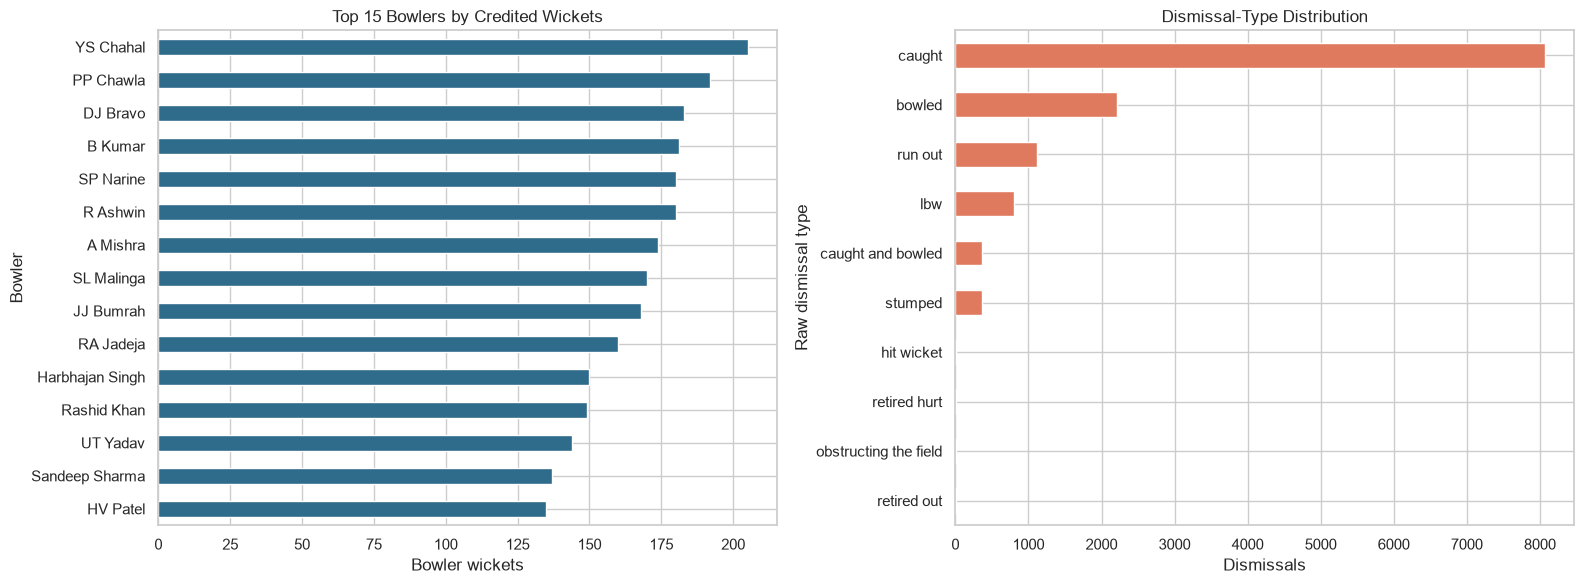

In [14]:
BOWLER_WICKET_TYPES = {"bowled", "caught", "caught and bowled", "lbw", "stumped", "hit wicket"}
dismissal_counts = deliveries["dismissal_kind"].value_counts()
bowler_wicket_rows = deliveries.loc[deliveries["dismissal_kind"].isin(BOWLER_WICKET_TYPES)]
top_bowlers = bowler_wicket_rows["bowler"].value_counts().head(15)
wickets_by_team = bowler_wicket_rows["bowling_team"].value_counts()
season_wickets = deliveries_with_season.loc[deliveries_with_season["dismissal_kind"].isin(BOWLER_WICKET_TYPES)].groupby("season", sort=False).size().rename("bowler_wickets")
display(dismissal_counts.to_frame("dismissals")); display(top_bowlers.to_frame("bowler_wickets")); display(wickets_by_team.to_frame("bowler_wickets")); display(season_wickets.to_frame())
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_bowlers.sort_values().plot.barh(ax=axes[0], color=CHART_COLOR)
dismissal_counts.sort_values().plot.barh(ax=axes[1], color=ACCENT_COLOR)
axes[0].set(title="Top 15 Bowlers by Credited Wickets", xlabel="Bowler wickets", ylabel="Bowler")
axes[1].set(title="Dismissal-Type Distribution", xlabel="Dismissals", ylabel="Raw dismissal type")
plt.tight_layout(); plt.show()

## 12. Player analysis

Player participation is inferred from name fields because there is no stable player ID or master table. Initial-based names may be ambiguous, and identity variations cannot be resolved reliably during EDA.

,unique_names
Batters,673
Bowlers,530
Non-strikers,663
Dismissed players,629
Fielders,607
Player-of-match recipients,291
Union of available player names,741


,batter_runs,bowler_wickets,player_of_match_awards
V Kohli,"8,014.00",NaN,18.00
S Dhawan,"6,769.00",NaN,NaN
RG Sharma,"6,630.00",NaN,19.00
DA Warner,"6,567.00",NaN,18.00
SK Raina,"5,536.00",NaN,14.00
MS Dhoni,"5,243.00",NaN,17.00
AB de Villiers,"5,181.00",NaN,25.00
CH Gayle,"4,997.00",NaN,22.00
RV Uthappa,"4,954.00",NaN,NaN
KD Karthik,"4,843.00",NaN,NaN


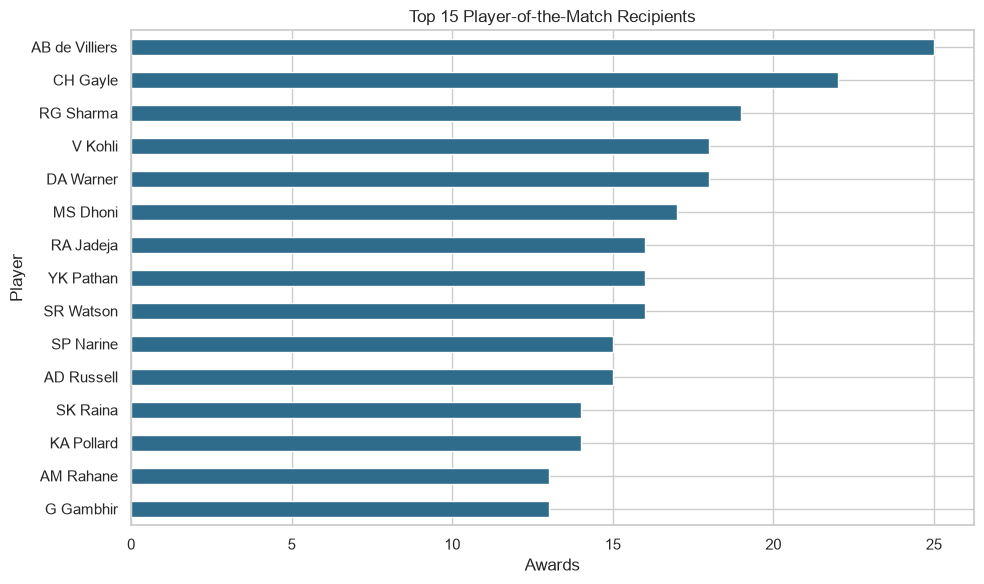

In [15]:
player_counts = pd.Series({"Batters": deliveries["batter"].nunique(), "Bowlers": deliveries["bowler"].nunique(), "Non-strikers": deliveries["non_striker"].nunique(), "Dismissed players": deliveries["player_dismissed"].nunique(), "Fielders": deliveries["fielder"].nunique(), "Player-of-match recipients": matches["player_of_match"].nunique(), "Union of available player names": len(all_players)}, name="unique_names")
top_player_awards = matches["player_of_match"].value_counts().head(15)
display(player_counts.to_frame())
display(pd.concat([top_batters.rename("batter_runs"), top_bowlers.rename("bowler_wickets"), top_player_awards.rename("player_of_match_awards")], axis=1))
ax = top_player_awards.sort_values().plot.barh(figsize=(10, 6), color=CHART_COLOR, title="Top 15 Player-of-the-Match Recipients")
ax.set(xlabel="Awards", ylabel="Player"); plt.tight_layout(); plt.show()

## 13. Venue / city analysis

Rankings use raw labels. Candidate aliases are surfaced for review and are not replaced.

,matches
venue,
Eden Gardens,77
Wankhede Stadium,73
M Chinnaswamy Stadium,65
Feroz Shah Kotla,60
"Rajiv Gandhi International Stadium, Uppal",49
"MA Chidambaram Stadium, Chepauk",48
Sawai Mansingh Stadium,47
Dubai International Cricket Stadium,46
"Wankhede Stadium, Mumbai",45


,matches
city,
Mumbai,173
Kolkata,93
Delhi,90
Chennai,85
Hyderabad,77
Bangalore,65
Chandigarh,61
Jaipur,57
Pune,51


,candidate_group,raw_venue,matches
0,Arun Jaitley Stadium,Arun Jaitley Stadium,14
1,Arun Jaitley Stadium,"Arun Jaitley Stadium, Delhi",16
2,Brabourne Stadium,Brabourne Stadium,10
3,Brabourne Stadium,"Brabourne Stadium, Mumbai",17
4,Eden Gardens,Eden Gardens,77
5,Eden Gardens,"Eden Gardens, Kolkata",16
6,M Chinnaswamy Stadium,M Chinnaswamy Stadium,65
7,M Chinnaswamy Stadium,M.Chinnaswamy Stadium,15
8,M Chinnaswamy Stadium,"M Chinnaswamy Stadium, Bengaluru",14
9,Wankhede Stadium,Wankhede Stadium,73


,matches
city,
Bangalore,65
Bengaluru,29


,missing_city_rows
venue,
Dubai International Cricket Stadium,33
Sharjah Cricket Stadium,18


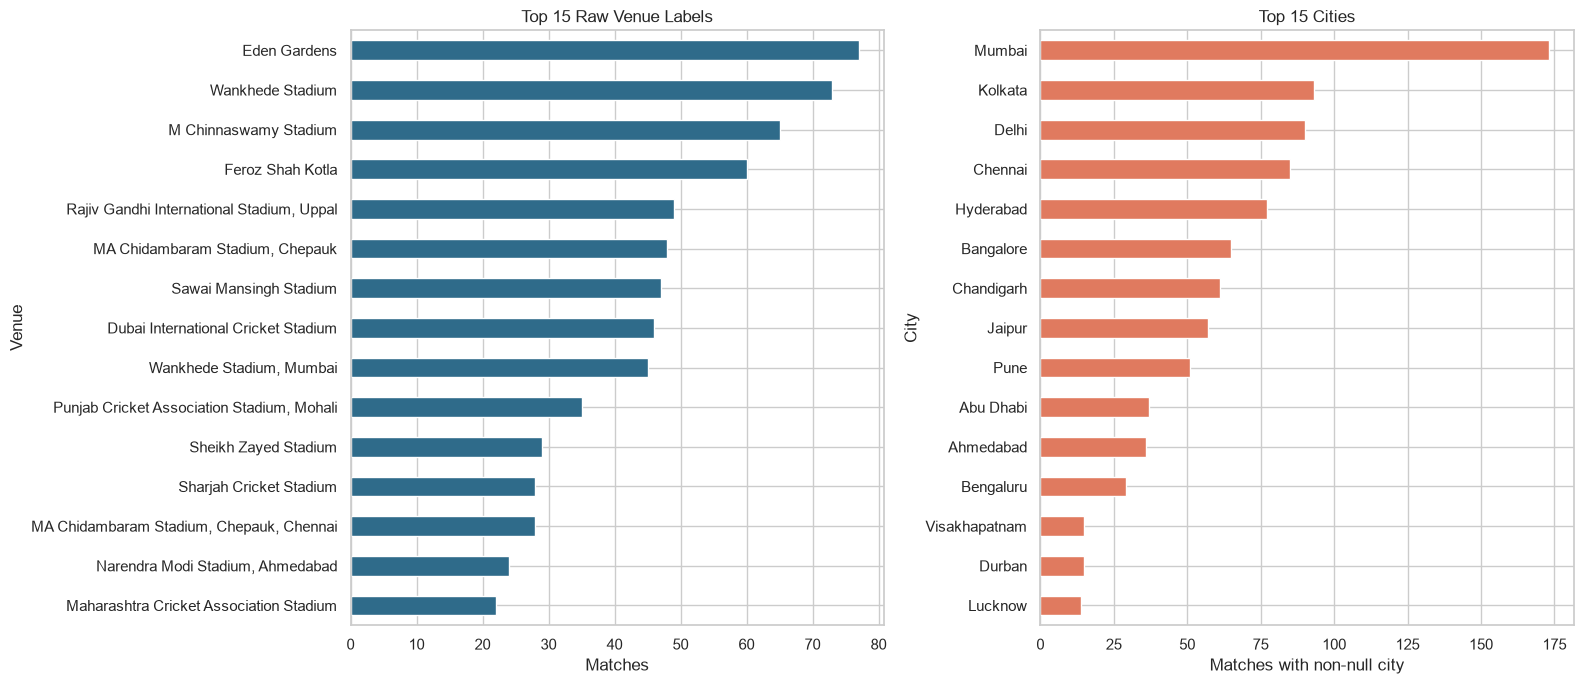

In [16]:
venue_counts, city_counts = matches["venue"].value_counts(), matches["city"].value_counts()
candidate_aliases = {
    "Arun Jaitley Stadium": ["Arun Jaitley Stadium", "Arun Jaitley Stadium, Delhi"],
    "Brabourne Stadium": ["Brabourne Stadium", "Brabourne Stadium, Mumbai"],
    "Eden Gardens": ["Eden Gardens", "Eden Gardens, Kolkata"],
    "M Chinnaswamy Stadium": ["M Chinnaswamy Stadium", "M.Chinnaswamy Stadium", "M Chinnaswamy Stadium, Bengaluru"],
    "Wankhede Stadium": ["Wankhede Stadium", "Wankhede Stadium, Mumbai"],
}
alias_rows = [{"candidate_group": group, "raw_venue": name, "matches": int(venue_counts[name])} for group, names in candidate_aliases.items() for name in names if name in venue_counts.index]
display(venue_counts.head(20).to_frame("matches")); display(city_counts.to_frame("matches")); display(pd.DataFrame(alias_rows))
display(city_counts.reindex(["Bangalore", "Bengaluru"]).to_frame("matches"))
display(matches.loc[matches["city"].isna(), "venue"].value_counts().to_frame("missing_city_rows"))
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
venue_counts.head(15).sort_values().plot.barh(ax=axes[0], color=CHART_COLOR)
city_counts.head(15).sort_values().plot.barh(ax=axes[1], color=ACCENT_COLOR)
axes[0].set(title="Top 15 Raw Venue Labels", xlabel="Matches", ylabel="Venue")
axes[1].set(title="Top 15 Cities", xlabel="Matches with non-null city", ylabel="City")
plt.tight_layout(); plt.show()

## 14. Match outcome analysis

Run and wicket margins have different units, so they are summarized and plotted separately. Ties and no-results have no numeric result margin.

,matches
result,
wickets,578
runs,498
tie,14
no result,5


,count,mean,std,min,25%,50%,75%,max
result,,,,,,,,
runs,498.00,30.10,26.74,1.00,11.00,22.00,41.00,146.00
wickets,578.00,6.19,1.85,1.00,5.00,6.00,7.00,10.00


,id,season,date,team1,team2,winner,result
66,392190,2009,2009-04-23,Kolkata Knight Riders,Rajasthan Royals,Rajasthan Royals,tie
130,419121,2009/10,2010-03-21,Chennai Super Kings,Kings XI Punjab,Kings XI Punjab,tie
328,598004,2013,2013-04-07,Sunrisers Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,tie
342,598017,2013,2013-04-16,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,tie
416,729315,2014,2014-04-29,Kolkata Knight Riders,Rajasthan Royals,Rajasthan Royals,tie
475,829741,2015,2015-04-21,Rajasthan Royals,Kings XI Punjab,Kings XI Punjab,tie
610,1082625,2017,2017-04-29,Gujarat Lions,Mumbai Indians,Mumbai Indians,tie
705,1175365,2019,2019-03-30,Kolkata Knight Riders,Delhi Capitals,Delhi Capitals,tie
746,1178426,2019,2019-05-02,Mumbai Indians,Sunrisers Hyderabad,Mumbai Indians,tie
757,1216493,2020/21,2020-09-20,Delhi Capitals,Kings XI Punjab,Delhi Capitals,tie


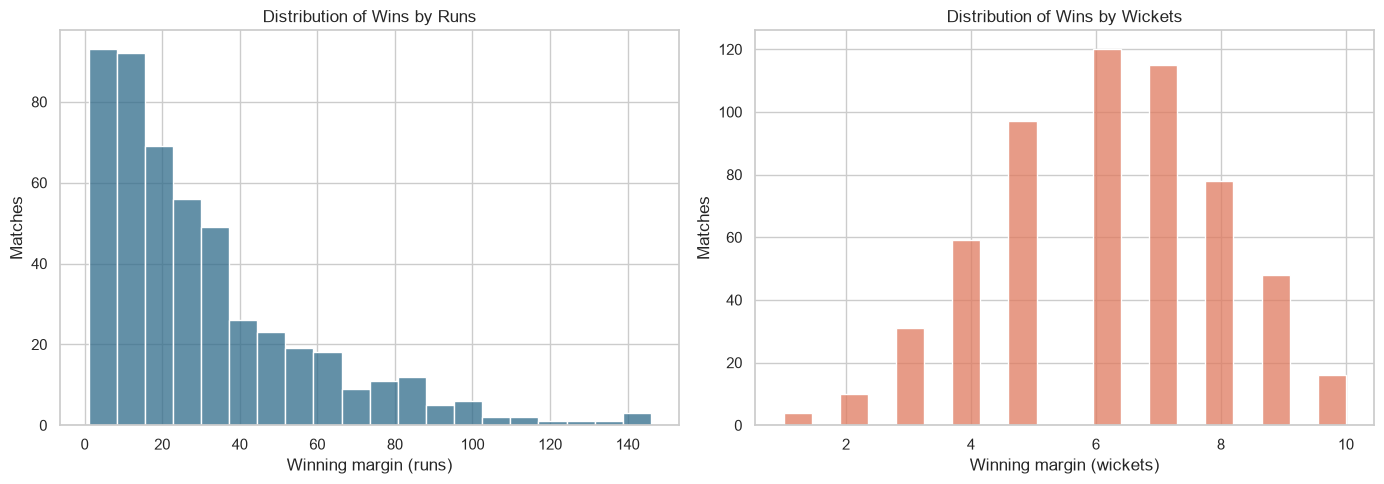

In [17]:
result_counts = matches["result"].value_counts()
margin_summary = matches.loc[matches["result"].isin(["runs", "wickets"])].groupby("result")["result_margin"].describe()
super_over_matches = matches.loc[matches["super_over"].eq("Y"), ["id", "season", "date", "team1", "team2", "winner", "result"]]
display(result_counts.to_frame("matches")); display(margin_summary); display(super_over_matches)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, outcome, color in zip(axes, ["runs", "wickets"], [CHART_COLOR, ACCENT_COLOR]):
    values = matches.loc[matches["result"].eq(outcome), "result_margin"].dropna()
    sns.histplot(values, bins=20, ax=ax, color=color)
    unit = "runs" if outcome == "runs" else "wickets"
    ax.set(title=f"Distribution of Wins by {unit.title()}", xlabel=f"Winning margin ({unit})", ylabel="Matches")
plt.tight_layout(); plt.show()

## 15. Data-quality observations

These executed observations should feed into Phase 4:

- Season labels mix tournament-style values (`2007/08`, `2009/10`, `2020/21`) with single years.
- Team strings reflect historical franchise changes and naming evolution; mappings require documented identity decisions.
- Several venues appear with punctuation or city-suffix variants.
- `Bangalore` and `Bengaluru` coexist as city values.
- Missing cities occur at Dubai International Cricket Stadium and Sharjah Cricket Stadium; any fill must be explicit.
- Delivery nulls are largely conditional: extras fields are absent without extras and dismissal fields are absent when not applicable.
- Overs are zero-based (`0`–`19`), and ball numbers can exceed six because illegal deliveries extend an over.
- Player names have no stable ID/master table, making identity matching uncertain.
- Historical formats use multiple playoff terms, including Semi Final, Elimination Final, and 3rd Place Play-Off.
- Missing winners and Player-of-the-Match values occur in no-result matches and are not ordinary data defects.

## 16. Key analytical findings

The following evidence-based statements are generated directly from notebook calculations.

In [18]:
top_winning_team = team_summary["wins"].idxmax()
highest_win_pct_team = team_summary["win_percentage"].idxmax()
findings = [
    f"The dataset contains {len(matches):,} matches across {matches['season'].nunique()} raw season labels and {len(deliveries):,} delivery rows.",
    f"{matches_by_season.idxmax()} has the most represented matches ({matches_by_season.max():,}).",
    f"{top_winning_team} has the most wins under one raw team name ({team_summary.loc[top_winning_team, 'wins']:,}).",
    f"{highest_win_pct_team} has the highest raw-name win percentage ({team_summary.loc[highest_win_pct_team, 'win_percentage']:.1f}%), using wins divided by all appearances.",
    f"The toss winner also won {toss_winner_won.sum():,} of {len(decided_matches):,} decided matches ({toss_winner_won.mean() * 100:.1f}%); this does not establish causation.",
    f"{top_batters.index[0]} leads aggregate batter runs with {top_batters.iloc[0]:,}.",
    f"{top_bowlers.index[0]} leads credited bowler wickets with {top_bowlers.iloc[0]:,} under the stated dismissal convention.",
    f"{top_player_awards.index[0]} has the most Player-of-the-Match awards ({top_player_awards.iloc[0]:,}).",
    f"{venue_counts.index[0]} is the most frequent raw venue label ({venue_counts.iloc[0]:,} matches).",
    f"There are {result_counts.get('tie', 0):,} ties, {result_counts.get('no result', 0):,} no-results, and {matches['super_over'].eq('Y').sum():,} super-over matches.",
]
for number, finding in enumerate(findings, start=1):
    print(f"{number}. {finding}")

1. The dataset contains 1,095 matches across 17 raw season labels and 260,920 delivery rows.
2. 2013 has the most represented matches (76).
3. Mumbai Indians has the most wins under one raw team name (144).
4. Rising Pune Supergiant has the highest raw-name win percentage (62.5%), using wins divided by all appearances.
5. The toss winner also won 554 of 1,090 decided matches (50.8%); this does not establish causation.
6. V Kohli leads aggregate batter runs with 8,014.
7. YS Chahal leads credited bowler wickets with 205 under the stated dismissal convention.
8. AB de Villiers has the most Player-of-the-Match awards (25).
9. Eden Gardens is the most frequent raw venue label (77 matches).
10. There are 14 ties, 5 no-results, and 14 super-over matches.


## 17. Phase 4 handoff

Cleaning decisions to consider next—none are implemented here:

1. Create a canonical season field while preserving the source label.
2. Decide which renamed teams represent continuing franchises and publish the mapping.
3. Build a reviewed canonical venue mapping.
4. Standardize Bangalore/Bengaluru while retaining original values for traceability.
5. Decide whether Dubai and Sharjah cities may be filled from venue context, recording affected rows.
6. Convert dates to datetime with validation.
7. Preserve structurally valid nulls rather than filling them indiscriminately.
8. Define legal-ball handling before balls-faced or economy calculations.
9. Standardize terminology such as `batsman_runs` only in processed data.
10. Preserve historical match-type detail or create a separate documented grouping.
11. Treat player names as display identifiers unless a defensible identity mapping is available.